# 🛠️ **OPEN PIT MINING SCHEDULE SIMULATION**

This notebook simulates a simplified open pit mining schedule using a synthetic block model. It aims to demonstrate core concepts used in mine planning and pit optimisation, including:

- Applying an economic cut-off to classify ore and waste
- Binning blocks into benches and pushbacks
- Assigning mining phases based on block value and accessibility
- Simulating period-based extraction under equipment capacity constraints
- Visualising the evolving mining sequence in 2D and 3D

### ⚙️ Key Concepts

- **Economic Cut-off**: Blocks below a given $/tonne threshold are classified as waste.
- **Benches & Pushbacks**: Mining advances downward in benches (Z) and outward in pushbacks (X/Y).
- **Scheduling**: Blocks are grouped into periods based on movement limits and ore production targets.
- **Visualisation**: Plan view, Gantt-style sequences, and 3D animations help understand mining progression.

This is a standalone scheduling approximation (not a full pit optimiser), but it illustrates key logic for phase design, sequencing, and production control.

---

## 🔍 **Step 0: Load the Block Model**

Before we begin, we load the synthetic block model file containing block locations, economic values, physical properties, and classifications (ore/waste, lithology, etc.).

The notebook supports `.csv`, `.json`, and `.parquet` formats.

We also import the necessary libraries and set the file path to access the data.


In [40]:
# ======================================================================
# 📦 STEP 0: LOAD THE BLOCK MODEL ###
# ======================================================================

import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import pyarrow.parquet as pq
import plotly.express as px
import os
from scipy.spatial import ConvexHull
from matplotlib.patches import Rectangle
import math
# --- File path setup ---
file_path = "../data/"
filename_base = "synthetic_block_model"
file_type = ".parquet"
file = os.path.join(file_path, f"{filename_base}{file_type}")
print(f"File path: {file}")

chunk_size = 100000  # Number of rows to read at a time

# --- Load Block Model ---
parquet_file = pq.ParquetFile(file)
total_rows = parquet_file.metadata.num_rows
total_batches = (total_rows + chunk_size - 1) // chunk_size  # Calculate total number of batches
total_read_rows = 0

chunks = []

for batch in tqdm(parquet_file.iter_batches(batch_size=chunk_size),
				  desc="Loading block model", total=total_batches):
	block_df = batch.to_pandas()
	total_read_rows += len(block_df)
	chunks.append(block_df)

print(f"Number of chunks loaded: {len(chunks)}")
print(f"Total number of rows read: {total_read_rows}")
print(f"Total number of rows in original file: {total_rows}")
print(f"Block model loaded successfully.")

# Check if all rows have been read
if total_read_rows == total_rows:
	print("All rows have been read successfully.")
else:
	print("Some rows are missing.")

File path: ../data/synthetic_block_model.parquet


Loading block model:   0%|          | 0/10 [00:00<?, ?it/s]

Number of chunks loaded: 10
Total number of rows read: 995328
Total number of rows in original file: 995328
Block model loaded successfully.
All rows have been read successfully.


## ⚙️ **Step 1: Define Parameters & Initial Settings**

Here we define all user-adjustable parameters related to:

- **Geometry**: Bench height and pushback width
- **Production targets**: Equipment movement limits, ore production goals
- **Economic filtering**: $/tonne cut-off for ore vs waste
- **Scheduling**: Period duration (e.g. 365 days per period)
- **Mining Phases**: Number of mining phases (e.g. 5)
- **Interactivity**: Dropdown filters for phase, block type, and depth level (Z)

These parameters drive the scheduling logic and visualisation controls used throughout the notebook.


In [41]:
# ==============================================================================
# 📦 STEP 1: USER-DEFINED PARAMETERS
# ==============================================================================

# ------------------------------------------------------------------------------
# 🔧 GLOBAL PARAMETERS, TOGGLES & VISUALISATION CONTROLS
# ------------------------------------------------------------------------------

oz_to_g = 31.1035
lb_to_kg = 2.20462

enable_diagnostics = True
preview_mode = True

# ------------------------------------------------------------------------------
# 📐 BLOCK MODEL & PIT DESIGN PARAMETERS
# ------------------------------------------------------------------------------

buffer_margin = 100               	# metres of waste buffer added around block model
default_spacing = 10              	# default block spacing (m)
bench_height = 10                 	# vertical mining bench height (m)
min_mining_width = 20             	# minimum horizontal step width for pushbacks (m)

ramp_gradient = 10                	# ramp gradient (1:10 means 10)
inter_ramp_angle_deg = 45         	# Inter-ramp slope angle (degrees)
catch_berm_interval = 30          	# vertical interval for catch berms (m)
catch_berm_width = 10             	# horizontal width of catch berms (m)
slope_penalty_factor = 0.85       	# slope penalty applied to fault zones (1.0 = no penalty)
final_wall_angle_deg = 52     		# steeper slope at depth
final_wall_cutoff_depth = 100 		# bottom X metres of pit

z_interval = 20                   	# vertical interval used for plotting phase slices (m)
n_phases = 5                      	# number of mining phases to define

pit_shell_padding_x = 100         	# Extra horizontal margin for shell expansion (m)
pit_shell_padding_y = 100		  	# Extra vertical margin for shell expansion (m)

# ------------------------------------------------------------------------------
# ⚙️ EQUIPMENT & PRODUCTION SETTINGS
# ------------------------------------------------------------------------------

equipment_fleet = [
	{"type": "Truck", "capacity_t": 150, "count": 45, "width": 7.6, "length": 13.4},
	{"type": "Shovel", "capacity_t": 830, "count": 5}
]

truck_width = 8.0  								# metres
road_width_required = truck_width * 3.5 + 15  	# 3.5x width + 15m safety

equipment_capacity_tpd = 450_000   	# daily total movement capacity (ore + waste)
target_ore_tpd = 115_000           	# daily ore production target (t/day)
period = 1							# starting period (1 = month)
days_per_period = 30				# number of days in each period (e.g. month, quarter, year)

target_ore_per_period = target_ore_tpd * days_per_period
target_total_movement_per_period = equipment_capacity_tpd * days_per_period

# ------------------------------------------------------------------------------
# 💰 ECONOMIC PARAMETERS
# ------------------------------------------------------------------------------

use_smu_for_valuation = False  		# If True, use smoothed value_smu for net_value calculation

# Base costs (AUD)
mining_cost_per_tonne = 3.50
processing_cost_per_tonne = 12.00
discount_rate = 0.08

# Commodity prices (USD)
gold_price_usd_per_oz = 2500
copper_price_usd_per_lb = 4.00
nsr_deduction_rate = 0.05

# Exchange rates
exchange_rates = {
	"AUD": 1.0,
	"USD": 1 / 1.5,
	"CAD": 0.91
}

# Converted to AUD
gold_price_aud_per_oz = gold_price_usd_per_oz / exchange_rates["USD"]
gold_price_aud_per_g = gold_price_aud_per_oz / oz_to_g
copper_price_aud_per_lb = copper_price_usd_per_lb / exchange_rates["USD"]

# Recoveries
gold_recovery = 0.90
copper_recovery = 0.88

# ------------------------------------------------------------------------------
# 🏗️ CAPITAL COSTS
# ------------------------------------------------------------------------------

initial_capex = 500_000_000        # AUD
sustaining_capex = 20_000_000      # optional placeholder for later periods

# ------------------------------------------------------------------------------
# 📊 PHASE PARAMETERS
# ------------------------------------------------------------------------------

default_xrange = (1000, 2500)
default_yrange = (700, 1700)

phase_unlock = {
	"Phase 0": 0,
	"Phase 1": 1,
	"Phase 2": 6,
	"Phase 3": 12,
	"Phase 4": 18,
	"Phase 5": 24
}


# ------------------------------------------------------------------------------
# 📋 SCHEDULE RAMP-UP PARAMETERS
# ------------------------------------------------------------------------------

total_periods = 120
peak_period = 26
peak_tonnage = target_total_movement_per_period * 1.2
min_tonnage = target_total_movement_per_period * 0.4

ramp_up_period = 5            		# number of periods to reach peak production
ramp_down_period = 45                	# number of periods to ramp down production
ramp_down_adjustment = 0.15           		# adjustment factor for ramp down (0.5 = 50% of peak production)
steady_tonnage = target_total_movement_per_period  # baseline steady rate
min_tonnage = steady_tonnage * 0.5


# ------------------------------------------------------------------------------
# 📋 UI CONTROL PLACEHOLDERS
# ------------------------------------------------------------------------------

selected_block_type = "All"
selected_phase = "All"
display_metric = "tonnes"


### 🔹 **Step 1.2: Add Buffer Waste Blocks Around the Block Model**

To support realistic pit shell development, a buffer zone of waste blocks is generated around the existing block model. This allows the pit shell to expand beyond the orebody, accommodating:

- Slope constraints (inter-ramp angle, catch berms)
- Highwall formation and working space
- Ramp access development
- A more natural pit shape that does not clip exactly to the orebody boundary

The buffer:
- Extends the block model boundary by a user-defined `buffer_margin` (e.g. 100 m) in the X and Y directions
- Uses the same block dimensions and vertical resolution as the main model
- Assigns zero grade and net negative value (uneconomic waste)
- Is flagged as `"buffer"` in the optional `source` column for tracking and visualisation

These blocks are not included in the production schedule unless required for prestripping or access, but they enable slope-controlled pit shell growth and improve realism in downstream scheduling and visualisation steps.

In [42]:
# ======================================================================
# 📦 STEP 1.2: ADD BUFFER WASTE BLOCKS AROUND BLOCK MODEL ###
# ======================================================================

import numpy as np

processed_chunks = []

for block_df in tqdm(chunks, desc="Processing block model"):
	# Sort block_df by coordinates before computing spacing
	block_df = block_df.sort_values(by=["x", "y", "z"]).reset_index(drop=True)

	# Compute spacing (ensure spacing is positive)
	dx = block_df["x"].diff().replace(0, np.nan).dropna().median()
	dy = block_df["y"].diff().replace(0, np.nan).dropna().median()
	dz = block_df["z"].diff().replace(0, np.nan).dropna().median()

	# Safety fallback if diff returns 0
	dx = dx if dx and dx > 0 else default_spacing
	dy = dy if dy and dy > 0 else default_spacing
	dz = dz if dz and dz > 0 else default_spacing

	# Get model extents
	x_min, x_max = block_df["x"].min(), block_df["x"].max()
	y_min, y_max = block_df["y"].min(), block_df["y"].max()
	z_vals = block_df["z"].unique()

	# Limit buffer blocks to top N benches (e.g., top 2)
	n_top_benches = 2
	top_z_vals = sorted(block_df["z"].unique())[-n_top_benches:]

	# Define extended padded range
	def safe_arange(start, stop, step, label):
		count = int(np.ceil((stop - start) / step))
		if count > 5000:
			raise ValueError(f"❌ Too many values in {label} axis: {count:,}. Adjust buffer size or increase spacing.")
		return np.linspace(start, stop, count)

	# Safer buffer spacing (consider 2x spacing if needed)
	buffer_dx = dx * 2
	buffer_dy = dy * 2

	x_range_ext = safe_arange(x_min - buffer_margin, x_max + buffer_margin + buffer_dx, buffer_dx, "X")
	y_range_ext = safe_arange(y_min - buffer_margin, y_max + buffer_margin + buffer_dy, buffer_dy, "Y")

	# Create meshgrid of all extended coordinates
	xx, yy, zz = np.meshgrid(x_range_ext, y_range_ext, top_z_vals, indexing="ij")
	buffer_coords = pd.DataFrame({
		"x": xx.ravel(),
		"y": yy.ravel(),
		"z": zz.ravel()
	})

	# Identify which blocks are *not* in the original model
	original_coords = block_df[["x", "y", "z"]].drop_duplicates()
	buffer_coords = buffer_coords.merge(original_coords, how="left", on=["x", "y", "z"], indicator=True)
	buffer_coords = buffer_coords[buffer_coords["_merge"] == "left_only"].drop(columns=["_merge"])

	# Assign buffer block attributes
	buffer_coords["class"] = "Waste"
	buffer_coords["Au_grade"] = 0.0
	buffer_coords["Cu_grade"] = 0.0
	buffer_coords["density"] = block_df["density"].mean()
	buffer_coords["tonnes"] = buffer_coords["density"] * dx * dy * dz
	buffer_coords["volume_m3"] = dx * dy * dz
	buffer_coords["value_Au_per_tonne"] = 0.0
	buffer_coords["value_Cu_per_tonne"] = 0.0
	buffer_coords["value_per_tonne"] = 0.0
	buffer_coords["net_value"] = -mining_cost_per_tonne  # Always uneconomic
	buffer_coords["source"] = "buffer"  # Optional: useful to distinguish them

	# Align columns with block_df
	for col in block_df.columns:
		if col not in buffer_coords.columns:
			buffer_coords[col] = np.nan
	buffer_coords = buffer_coords[block_df.columns]  # Ensure column order

	# Append to block_df
	block_df = pd.concat([block_df, buffer_coords], ignore_index=True)
	
	# Store the processed chunk
	processed_chunks.append(block_df)

# Combine all processed chunks
final_block_df = pd.concat(processed_chunks, ignore_index=True)

print(f"Total number of rows in final block model: {len(final_block_df)}")
print(f"Number of columns in final block model: {len(final_block_df.columns)}")
print(f"Columns in final block model: {final_block_df.columns.tolist()}")
print(f"Block model loaded and processed successfully.")

Processing block model:   0%|          | 0/10 [00:00<?, ?it/s]

Total number of rows in final block model: 1076948
Number of columns in final block model: 37
Columns in final block model: ['x', 'y', 'z', 'concentric_zone', 'lith_code', 'processing_route', 'Au_grade', 'Cu_grade', 'fault_zone_category', 'density', 'mag_sus', 'resistivity', 'gamma', 'UCS', 'RMR', 'Axb', 'BWi', 'DWi', 'grindability', 'floatability_index', 'reagent_demand', 'stratigraphy', 'alteration', 'grain_size', 'oxidation_zone', 'fault_category', 'currency', 'value_Au_per_tonne', 'value_Cu_per_tonne', 'value_per_tonne', 'class', 'domain', 'volume_m3', 'tonnes', 'block_id', 'value_smu', 'class_smu']
Block model loaded and processed successfully.


## 🧮 Step 2: Pit Shell, Phases, Prestrip & Scheduling
In this step, we simulate the progressive growth of a realistic open pit mine using geotechnical and operational constraints. The logic mimics how pit shells expand in the real world, factoring in:

🔍 What We Do in This Step:

**1. Define a Central Growth Point** \
The pit expands concentrically from the centre of the orebody.

**2. Apply Geotechnical Constraints** \
Based on the Inter-Ramp Angle (IRA) and Catch Berms, we calculate the maximum allowable lateral extent (radius) for each block by depth.

**3. Determine Shell Inclusion** \
Blocks are flagged as *within the pit shell* if they lie inside the allowable slope envelope.

**4. Apply Economic Filter** \
Only blocks with a value above the cut-off and within the pit geometry are selected.

**5. Assign Mining Phases by Value** \
Economic blocks are sorted and divided into mining phases (e.g., pre-strip, Phase 1, 2, etc.).

**6. Group into Pushbacks & Benches** \
Blocks are grouped by bench height and minimum mining width to enable equipment access and scheduling.

**7. Assign Periods Based on Capacity** \
Material is scheduled period-by-period, obeying the equipment capacity (tonnes moved per period).

**8. Build a Summary Table** \
We calculate total ore, waste, movement, profit, and discounted NPV per period to evaluate the viability of the schedule.

In [43]:
# ==============================================================================
# 🏗️ STEP 2: EXTRACTION SEQUENCE & PERIOD SCHEDULING
# ==============================================================================

import time

# ==============================================================================
# 1️⃣ ECONOMIC VALUE CALCULATION
# ==============================================================================

processed_chunks = []

for block_df in tqdm(chunks, desc="💰 Calculating Economic Values"):
	block_df["processing_cost"] = np.where(block_df["class"] == "Ore", processing_cost_per_tonne, 0)

	block_df["value_Au_per_tonne"] = (
		block_df["Au_grade"] * gold_price_aud_per_g * gold_recovery
	)
	block_df["value_Cu_per_tonne"] = (
		block_df["Cu_grade"] / 100 * 1000 * lb_to_kg *
		copper_price_aud_per_lb * copper_recovery
	)
	block_df["value_per_tonne"] = (
		block_df["value_Au_per_tonne"] + block_df["value_Cu_per_tonne"]
	) * (1 - nsr_deduction_rate)

	if use_smu_for_valuation and "value_smu" in block_df.columns:
		block_df["net_value"] = (
			block_df["value_smu"] - mining_cost_per_tonne - block_df["processing_cost"]
		)
	else:
		block_df["net_value"] = (
			block_df["value_per_tonne"] - mining_cost_per_tonne - block_df["processing_cost"]
		)

	processed_chunks.append(block_df)

print("✅ Economic value calculation completed.")

# ==============================================================================
# 2️⃣ INITIALISE BLOCK FLAGS
# ==============================================================================

all_blocks = pd.concat(processed_chunks, ignore_index=True)
all_blocks["block_type"] = np.where(all_blocks["class"] == "Ore", "Ore", "Waste")
print("✅ Block flags initialised.")

# ==============================================================================
# 3️⃣ PIT SHELL GEOMETRY CALCULATION (WITH SLOPE PENALTIES)
# ==============================================================================

x_centre = all_blocks["x"].mean()
y_centre = all_blocks["y"].mean()
max_z = all_blocks["z"].max()
ira_rad = math.radians(inter_ramp_angle_deg)
final_rad = math.radians(final_wall_angle_deg)

all_blocks["depth"] = all_blocks["z"].max() - all_blocks["z"]

# Compute block-wise slope angle depending on depth
all_blocks["slope_angle_deg"] = np.where(
	all_blocks["depth"] >= final_wall_cutoff_depth,
	final_wall_angle_deg,
	inter_ramp_angle_deg
)

all_blocks["slope_ratio"] = np.tan(np.radians(all_blocks["slope_angle_deg"]))

all_blocks["depth"] = max_z - all_blocks["z"]
all_blocks["num_berms"] = (all_blocks["depth"] // catch_berm_interval).astype(int)
all_blocks["berm_offset"] = all_blocks["num_berms"] * catch_berm_width

# Apply slope penalty for major fault zones
if "fault_zone_category" in all_blocks.columns:
	all_blocks["depth_adjusted"] = np.where(
		all_blocks["fault_zone_category"] == "major",
		all_blocks["depth"] * slope_penalty_factor,
		all_blocks["depth"]
	)
else:
	all_blocks["depth_adjusted"] = all_blocks["depth"]

# Calculate elliptical shell limits
all_blocks["allowed_radius"] = all_blocks["depth_adjusted"] * all_blocks["slope_ratio"]
all_blocks["effective_radius"] = all_blocks["allowed_radius"] - all_blocks["berm_offset"]

# Rescale X and Y distances based on pit shape
x_range = (all_blocks["x"].max() - all_blocks["x"].min()) + 2 * pit_shell_padding_x
y_range = (all_blocks["y"].max() - all_blocks["y"].min()) + 2 * pit_shell_padding_y

x_ratio = x_range / y_range  # Auto-calculate aspect ratio

# Optionally clip very small or negative radii (to avoid inf/NaNs)
all_blocks["effective_radius"] = all_blocks["effective_radius"].clip(lower=1.0)

# Semi-axes for each block
a = all_blocks["effective_radius"] * x_ratio  # semi-major axis in X
b = all_blocks["effective_radius"]            # semi-minor axis in Y

# Elliptical distance using standard ellipse equation
all_blocks["elliptical_distance"] = (
	((all_blocks["x"] - x_centre) ** 2) / (a ** 2) +
	((all_blocks["y"] - y_centre) ** 2) / (b ** 2)
)

# Assign shell inclusion
all_blocks["within_shell"] = all_blocks["elliptical_distance"] <= 1.0

# --- Access and economics ---
all_blocks["has_access"] = all_blocks["elliptical_distance"] <= all_blocks["depth_adjusted"] * ramp_gradient
all_blocks["is_economic"] = all_blocks["net_value"] >= 0

print("✅ Pit shell geometry calculated.")

# ==============================================================================
# 4️⃣ FILTER SCHEDULED BLOCKS (ECONOMIC + ACCESSIBLE)
# ==============================================================================

scheduled_blocks = all_blocks[
	all_blocks["within_shell"] & all_blocks["has_access"] & all_blocks["is_economic"]
].copy()
scheduled_blocks["phase"] = None
print("✅ Scheduled blocks filtered.")

# ==============================================================================
# 5️⃣ ADD PHASE 0: PRESTRIP (TOP BENCHES)
# ==============================================================================

top_benches = sorted(all_blocks["z"].unique())[-2:]
print(f"Top benches considered for prestrip: {top_benches}")

top_z = sorted(all_blocks["z"].unique())[-2:]
top_blocks = all_blocks[all_blocks["z"].isin(top_z)]

print("Total blocks in top benches:", len(top_blocks))
print("Non-economic blocks:", (~top_blocks["is_economic"]).sum())
print("Within shell:", top_blocks["within_shell"].sum())
print("Has access:", top_blocks["has_access"].sum())

# All three conditions
prestrip_conditions = (
	top_blocks["within_shell"] &
	top_blocks["has_access"] &
	(~top_blocks["is_economic"])
)
print("Prestrip candidates:", prestrip_conditions.sum())


prestrip_blocks = all_blocks[
	(all_blocks["within_shell"]) &
	(all_blocks["has_access"]) &
	(~all_blocks["is_economic"]) &
	(all_blocks["z"].isin(top_benches))
].copy()

print(f"Prestrip candidate count: {len(prestrip_blocks)}")

if not prestrip_blocks.empty:
	prestrip_blocks["phase"] = "Phase 0"
	prestrip_blocks["period"] = 0

	# Match column structure
	for col in scheduled_blocks.columns:
		if col not in prestrip_blocks.columns:
			prestrip_blocks[col] = np.nan

	scheduled_blocks = pd.concat(
		[prestrip_blocks[scheduled_blocks.columns], scheduled_blocks],
		ignore_index=True
	)
print("✅ Prestrip blocks added.")

# ==============================================================================
# 6️⃣ BIN BENCHES & PUSHBACKS
# ==============================================================================

scheduled_blocks["bench"] = (scheduled_blocks["z"] // bench_height).astype(int) * bench_height
scheduled_blocks["pushback_x"] = (scheduled_blocks["x"] // min_mining_width).astype(int) * min_mining_width
scheduled_blocks["pushback_y"] = (scheduled_blocks["y"] // min_mining_width).astype(int) * min_mining_width

scheduled_blocks["bench"] = pd.Categorical(
	scheduled_blocks["bench"],
	categories=sorted(scheduled_blocks["bench"].unique()),
	ordered=True
)

print("✅ Bench and pushback binning completed.")

# ==============================================================================
# 7️⃣ ASSIGN MINING PHASES (SPATIALLY USING PUSHBACKS)
# ==============================================================================

# Filter only unassigned blocks (those without a phase)
to_phase = scheduled_blocks[scheduled_blocks["phase"].isna()].copy()

# --- Spatial Aggregation by Pushbacks ---
pushback_bins = (
	to_phase.groupby(["pushback_y", "pushback_x"], dropna=False)
	.agg(
		mean_z=("z", "mean"),
		mean_value=("net_value", "mean"),
		total_tonnes=("tonnes", "sum")
	)
	.reset_index()
)

# --- Sort Pushbacks Top-Down, High-Value First ---
pushback_bins = pushback_bins.sort_values(
	by=["mean_z", "mean_value"], ascending=[False, False]
).reset_index(drop=True)

# --- Assign Phases ---
if len(pushback_bins) >= n_phases:
	pushback_bins["phase"] = pd.qcut(
		pushback_bins.index, q=n_phases,
		labels=[f"Phase {i+1}" for i in range(n_phases)]
	)
else:
	pushback_bins["phase"] = "Phase 1"  # fallback for too-few bins

# ✅ Sanity Check
print("Pushback bins with phase labels:")
print(pushback_bins.head())

# --- Merge back to assign phase ---
# Only using keys used in grouping above
to_phase = pd.merge(
	to_phase.drop(columns=["phase"], errors="ignore"),
	pushback_bins[["pushback_y", "pushback_x", "phase"]],
	on=["pushback_y", "pushback_x"],
	how="left",
	validate="many_to_one"
)

# ❗ Check if merge worked
if "phase" not in to_phase.columns:
	raise ValueError("❌ Phase assignment failed — 'phase' column missing after merge.")

# --- Update back into scheduled_blocks safely ---
scheduled_blocks.set_index(["x", "y", "z"], inplace=True)
to_phase.set_index(["x", "y", "z"], inplace=True)

scheduled_blocks.loc[to_phase.index, "phase"] = to_phase["phase"]
scheduled_blocks.reset_index(inplace=True)
print("✅ Mining phases assigned (spatially by pushback).")

scheduled_blocks["phase"] = pd.Categorical(
    scheduled_blocks["phase"],
    categories=sorted(scheduled_blocks["phase"].dropna().unique(), key=lambda x: int(x.split()[-1])),
    ordered=True
)

# ==============================================================================
# 8️⃣ ASSIGN EXTRACTION PERIODS BASED ON CAPACITY (WITH RAMP-UP CURVE)
# ==============================================================================

start_time = time.time()

# --- Prepare Bins ---
bin_groups = (
	scheduled_blocks
	.groupby(["bench", "pushback_y", "pushback_x"], sort=False, observed=True)
	.agg(
		total_tonnes=("tonnes", "sum"),
		mean_value=("net_value", "mean")
	)
	.reset_index()
)

# Add phase info to bin_groups (for smarter sorting)
bin_groups = pd.merge(
    bin_groups,
    scheduled_blocks[["bench", "pushback_y", "pushback_x", "phase"]].drop_duplicates(),
    on=["bench", "pushback_y", "pushback_x"],
    how="left"
)

# --- Sort by phase, then bench (top-down), then x/y spatial order ---
bin_groups = bin_groups.sort_values(
	by=["phase", "bench", "pushback_y", "pushback_x"],
	ascending=[True, True, True, True]
)

# --- Define ramp-up curve ---

def get_target_for_period(p: int) -> float:
	if p <= ramp_up_period:
		# Fast ramp-up to steady-state
		return min_tonnage + (steady_tonnage - min_tonnage) * (p / ramp_up_period)
	elif p <= ramp_down_period:
		# Maintain steady production
		return steady_tonnage
	else:
		# Ramp-down in steps
		step_decrement = steady_tonnage * ramp_down_adjustment
		step_down = steady_tonnage - step_decrement * (p - ramp_down_period)
		return max(step_down, min_tonnage) # Don't go below minimum

# --- Assign periods based on dynamic target ---
period = 1
moved_tonnes = 0
periods = []
target_tonnage = get_target_for_period(period)

for idx, row in tqdm(bin_groups.iterrows(), total=len(bin_groups), desc="⛏️ Assigning Periods"):
	if moved_tonnes + row["total_tonnes"] > target_tonnage:
		period += 1
		moved_tonnes = 0
		target_tonnage = get_target_for_period(period)
	moved_tonnes += row["total_tonnes"]
	periods.append(period)

bin_groups["period"] = periods

# --- Merge periods back ---
scheduled_blocks = pd.merge(
	scheduled_blocks.reset_index(drop=True),
	bin_groups[["bench", "pushback_y", "pushback_x", "period"]],
	on=["bench", "pushback_y", "pushback_x"],
	how="left",
	validate="many_to_one"
)

# Safety checks
if scheduled_blocks["period"].isna().any():
	missing = scheduled_blocks[scheduled_blocks["period"].isna()]
	print(f"❌ Found {len(missing)} blocks with missing period assignments!")
else:
	print("✅ All blocks successfully assigned to a period.")

scheduled_blocks = scheduled_blocks.dropna(subset=["period"])
scheduled_blocks["period"] = scheduled_blocks["period"].astype(int)

print(f"✅ Extraction sequencing complete in {time.time() - start_time:.2f} seconds.")

# ==============================================================================
# 9️⃣ SUMMARY TABLE: TONNES, STRIP RATIO
# ==============================================================================

summary = scheduled_blocks.groupby(
	["period", "block_type"], observed=True
	)["tonnes"].sum().unstack(fill_value=0)
summary["total_moved"] = summary.sum(axis=1)
summary["cumulative_movement"] = summary["total_moved"].cumsum()
summary["met_capacity"] = summary["total_moved"] <= target_total_movement_per_period
summary.reset_index(inplace=True)

ore_blocks = scheduled_blocks[scheduled_blocks["block_type"] == "Ore"]
summary["ore_tonnes"] = ore_blocks.groupby(
	"period", observed=True
	)["tonnes"].sum().reindex(summary["period"], fill_value=0)
summary["waste_tonnes"] = summary.get("Waste", 0)
summary["strip_ratio"] = np.where(
	summary["ore_tonnes"] > 0,
	summary["waste_tonnes"] / summary["ore_tonnes"],
	np.nan
)

# ==============================================================================
# 🔟 ECONOMIC METRICS, NPV & PAYBACK
# ==============================================================================

revenue = scheduled_blocks.groupby(
	"period", observed=True
	)["value_per_tonne"].sum().reindex(summary["period"], fill_value=0)
mining_cost = scheduled_blocks.groupby(
	"period", observed=True
	)["tonnes"].sum().reindex(summary["period"], fill_value=0) * mining_cost_per_tonne
processing_cost = (
	ore_blocks.groupby(
		"period", observed=True
		)["tonnes"].sum().reindex(summary["period"], fill_value=0) * processing_cost_per_tonne
)

summary["revenue"] = revenue
summary["mining_cost"] = mining_cost
summary["processing_cost"] = processing_cost
summary["profit"] = summary["revenue"] - summary["mining_cost"] - summary["processing_cost"]
summary["discount_factor"] = 1 / (1 + discount_rate) ** summary["period"]
summary["discounted_profit"] = summary["profit"] * summary["discount_factor"]
summary["cumulative_npv"] = summary["discounted_profit"].cumsum()
summary["cumulative_cashflow"] = summary["cumulative_npv"] - initial_capex
summary["payback_met"] = summary["cumulative_cashflow"] >= 0

payback_period = (
	summary[summary["payback_met"]].head(1)["period"].values[0]
	if summary["payback_met"].any()
	else None
)

print("✅ NPV, cashflow, and payback period calculated.")


💰 Calculating Economic Values:   0%|          | 0/10 [00:00<?, ?it/s]

✅ Economic value calculation completed.
✅ Block flags initialised.
✅ Pit shell geometry calculated.
✅ Scheduled blocks filtered.
Top benches considered for prestrip: [np.float64(705.0), np.float64(715.0)]
Total blocks in top benches: 27648
Non-economic blocks: 0
Within shell: 0
Has access: 76
Prestrip candidates: 0
Prestrip candidate count: 0
✅ Prestrip blocks added.
✅ Bench and pushback binning completed.
Pushback bins with phase labels:
   pushback_y  pushback_x  mean_z  mean_value  total_tonnes    phase
0        1180        1780   350.0  163.663993  1.212531e+06  Phase 1
1        1180        1800   350.0  160.692245  1.210583e+06  Phase 1
2        1200        1780   350.0  160.122188  1.214937e+06  Phase 1
3        1200        1800   350.0  156.305188  1.213133e+06  Phase 1
4        1200        1760   340.0  167.142388  1.181702e+06  Phase 1
✅ Mining phases assigned (spatially by pushback).


⛏️ Assigning Periods:   0%|          | 0/81580 [00:00<?, ?it/s]

✅ All blocks successfully assigned to a period.
✅ Extraction sequencing complete in 4.12 seconds.
✅ NPV, cashflow, and payback period calculated.


   period  actual_moved  target_movement
0       1  8.085651e+06        8100000.0
1       2  9.442962e+06        9450000.0
2       3  1.078728e+07       10800000.0
3       4  1.214723e+07       12150000.0
4       5  1.348388e+07       13500000.0
5       6  1.349924e+07       13500000.0
6       7  1.348601e+07       13500000.0
7       8  1.348861e+07       13500000.0
8       9  1.349395e+07       13500000.0
9      10  1.348854e+07       13500000.0


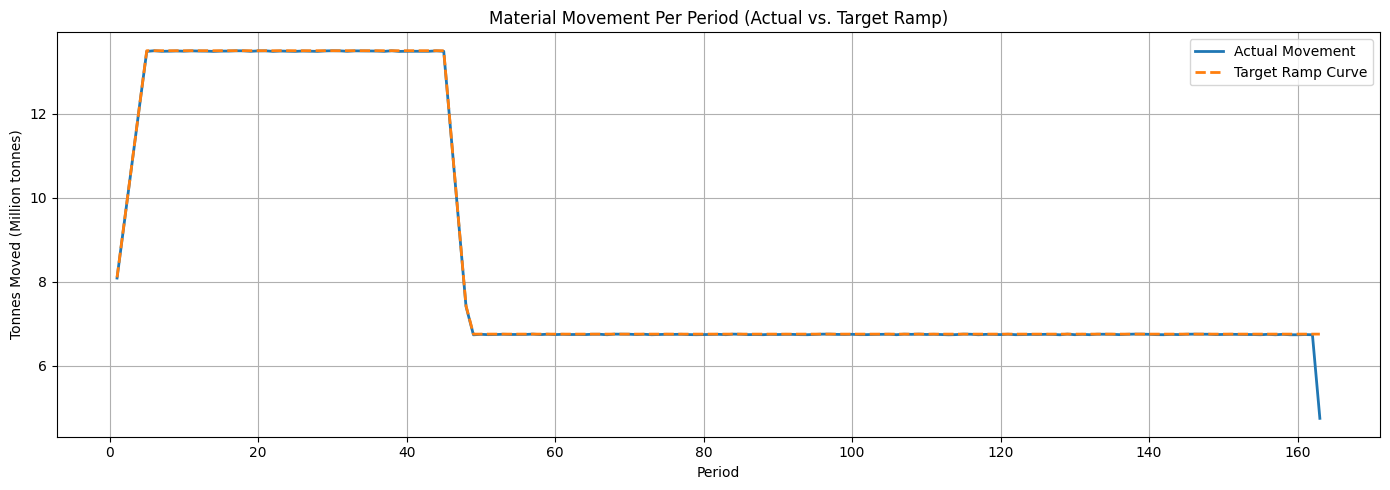

In [44]:
# --- Visualise Ramp Curve vs Actual Movement ---

import matplotlib.pyplot as plt

# 🧮 Recompute actual tonnes per period
summary_updated = (
	scheduled_blocks
	.groupby("period", as_index=False, observed=True)["tonnes"]
	.sum()
	.rename(columns={"tonnes": "actual_moved"})
)

# 📈 Compute target movement per period using your ramp function
summary_updated["target_movement"] = summary_updated["period"].apply(get_target_for_period)

# ✅ Optional sanity check
print(summary_updated[["period", "actual_moved", "target_movement"]].head(10))

# 📊 Plot
plt.figure(figsize=(14, 5))
plt.plot(summary_updated["period"], summary_updated["actual_moved"] / 1e6,
		 label="Actual Movement", linewidth=2)
plt.plot(summary_updated["period"], summary_updated["target_movement"] / 1e6,
		 '--', label="Target Ramp Curve", linewidth=2)

plt.title("Material Movement Per Period (Actual vs. Target Ramp)")
plt.xlabel("Period")
plt.ylabel("Tonnes Moved (Million tonnes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 3

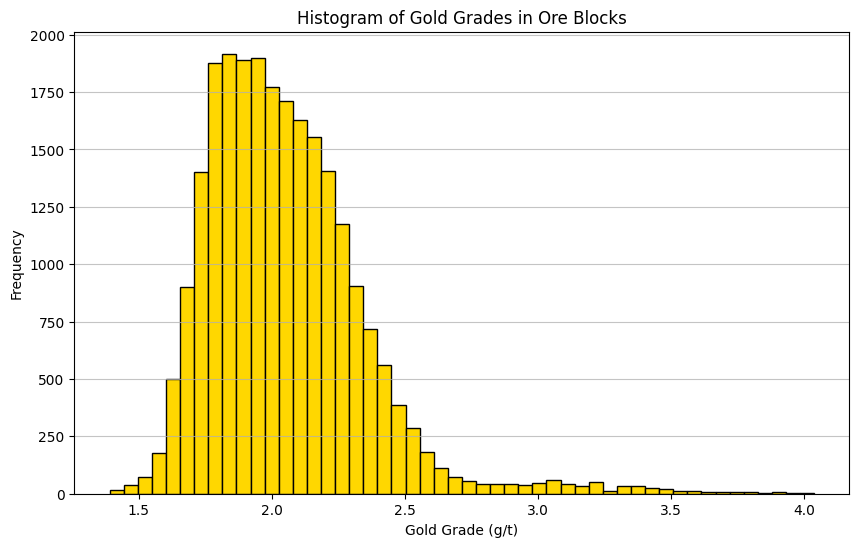

In [45]:
# Plot a histogram of Gold Grades in Ore Blocks
plt.figure(figsize=(10, 6))
plt.hist(ore_blocks["Au_grade"], bins=50, color='gold', edgecolor='black')
plt.title('Histogram of Gold Grades in Ore Blocks')
plt.xlabel('Gold Grade (g/t)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

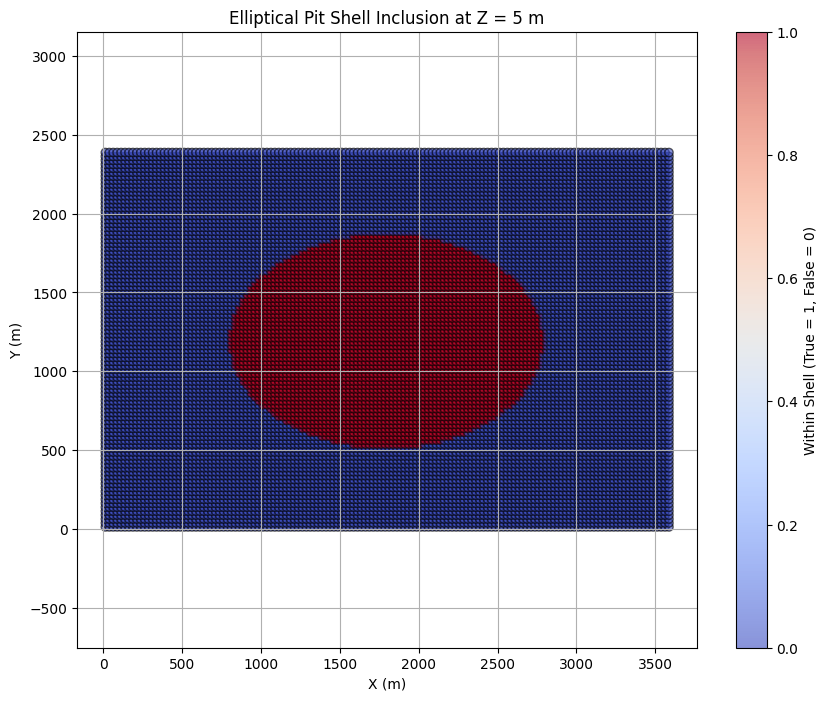

In [46]:
z_val = 5  # adjust for your RL
check_df = all_blocks[np.isclose(all_blocks["z"], z_val)]

plt.figure(figsize=(10, 8))
plt.scatter(
	check_df["x"], check_df["y"],
	c=check_df["within_shell"],
	cmap="coolwarm", edgecolor="k", alpha=0.6
)
plt.title(f"Elliptical Pit Shell Inclusion at Z = {z_val} m")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.colorbar(label="Within Shell (True = 1, False = 0)")
plt.axis("equal")
plt.grid(True)
plt.show()


In [47]:
#### FOR DEBUGGING ONLY ####
print("Ore blocks scheduled:", len(scheduled_blocks[scheduled_blocks["block_type"] == "Ore"]))
print("Net value summary:\n", block_df["net_value"].describe())
print("Economic blocks:", (block_df["net_value"] >= 0).sum())
valid_blocks = all_blocks[all_blocks["within_shell"] & all_blocks["has_access"]]
print("Within shell and accessible:", len(valid_blocks))
print("Of those, economic blocks:", len(valid_blocks[valid_blocks["net_value"] >= 0]))

for block_type in ["Ore", "Waste"]:
	print(f"\n--- {block_type} Blocks ---")
	subset = scheduled_blocks[scheduled_blocks["block_type"] == block_type]
	print(subset[["Au_grade", "Cu_grade", "value_per_tonne", "net_value"]].describe())


Ore blocks scheduled: 23813
Net value summary:
 count    95328.000000
mean         9.700280
std          1.912897
min          4.051887
25%          8.323829
50%          9.649307
75%         10.954304
max         22.246584
Name: net_value, dtype: float64
Economic blocks: 95328
Within shell and accessible: 81580
Of those, economic blocks: 81580

--- Ore Blocks ---
           Au_grade      Cu_grade  value_per_tonne     net_value
count  23813.000000  23813.000000     23813.000000  23813.000000
mean       2.051011      0.682636       286.913308    271.413308
std        0.297547      0.089281        31.254409     31.254409
min        1.390882      0.424784       243.198354    227.698354
25%        1.840998      0.621205       263.903811    248.403811
50%        2.009432      0.685507       279.922753    264.422753
75%        2.202865      0.746798       303.375898    287.875898
max        4.038278      0.959276       505.402015    489.902015

--- Waste Blocks ---
           Au_grade      C

In [48]:
print(scheduled_blocks["phase"].value_counts(dropna=False))


phase
Phase 1    34180
Phase 2    22256
Phase 3    14436
Phase 4     8080
Phase 5     2628
Name: count, dtype: int64


## 📊 Step 3: Visualise the Mining Phases

### ⛏️ Plan View with Phase Colours (Interactive)
- Select Z-slice using a dropdown
- View horizontal mining slices coloured by phase
- Future feature: add pit shell polygons and toggle individual phases on/off

In [49]:
# ======================================================================
# 📊 Step 3: VISUALISE MINING PHASES
# ======================================================================

import plotly.express as px
import plotly.graph_objects as go

# Define dropdown Z levels from scheduled_blocks
z_min, z_max = scheduled_blocks["z"].min(), scheduled_blocks["z"].max()
z_levels = np.arange(z_min, z_max + z_interval, z_interval)

# Extract unique phases for filtering
# Ensure Phase 0 is included and sort by numeric order if possible
unique_phases = sorted(
	scheduled_blocks["phase"].dropna().unique().tolist(),
	key=lambda x: int(x.split()[-1]) if isinstance(x, str) and x.startswith("Phase") else -1
)

# --- Widgets ---
z_dropdown = widgets.Dropdown(
	options=[(f"{int(z)} m", z) for z in z_levels],
	value=z_levels[len(z_levels) // 2],
	description="Z Level:",
	layout=widgets.Layout(width='300px')
)

phase_multiselect = widgets.SelectMultiple(
	options=unique_phases,
	value=tuple(unique_phases),
	description="Phases:",
	layout=widgets.Layout(width='300px')
)

metric_dropdown = widgets.Dropdown(
	options=["tonnes", "value", "volume"],
	value="tonnes",
	description="Display Metric:",
	layout=widgets.Layout(width='300px')
)

equip_mode_toggle = widgets.ToggleButtons(
	options=["Bench", "Period"],
	value="Bench",
	description="Equipment View:",
	layout=widgets.Layout(width='300px')
)

# Optional filter for fault zone category
fault_options = ["All"] + sorted(scheduled_blocks["fault_zone_category"].dropna().unique())
fault_filter = widgets.Dropdown(
	options=fault_options,
	value="All",
	description="Faults:",
	layout=widgets.Layout(width='300px')
)

# Optional filter for domain
domain_options = ["All"] + sorted(scheduled_blocks["domain"].dropna().unique())
domain_filter = widgets.Dropdown(
	options=domain_options,
	value="All",
	description="Domain:",
	layout=widgets.Layout(width='300px')
)

# --- Main Plot Function ---
def plot_interactive(z_value, selected_phases, metric, equip_mode):
	clear_output(wait=True)
	display(widgets.HBox([
		z_dropdown,
		phase_multiselect,
		metric_dropdown,
		equip_mode_toggle,
		fault_filter,
		domain_filter
	]))

	slice_df = scheduled_blocks[np.isclose(scheduled_blocks["z"], z_value)]

	if fault_filter.value != "All":
		slice_df = slice_df[slice_df["fault_zone_category"] == fault_filter.value]

	if domain_filter.value != "All":
		slice_df = slice_df[slice_df["domain"] == domain_filter.value]

	if selected_phases:
		slice_df = slice_df[slice_df["phase"].isin(selected_phases)]

	if slice_df.empty:
		print(f"No scheduled blocks at RL = {z_value}")
		return

	# --- Size scaling by metric ---
	if metric == "tonnes":
		size_vals = slice_df["tonnes"]
	elif metric == "value":
		size_vals = slice_df["value_per_tonne"]
	elif metric == "volume":
		size_vals = slice_df["volume_m3"]

	# --- Compute axis ranges from entire block model (not just slice) ---
	x_min, x_max = all_blocks["x"].min(), all_blocks["x"].max()
	y_min, y_max = all_blocks["y"].min(), all_blocks["y"].max()
	x_margin = 50
	y_margin = 50
	x_range = (x_min - x_margin, x_max + x_margin)
	y_range = (y_min - y_margin, y_max + y_margin)

	# --- Main Scatter ---
	fig = px.scatter(
		slice_df,
		x="x", y="y",
		color="phase",
		size=size_vals,
		size_max=20,
		title=f"Mining Phases at Z = {z_value:.1f} m",
		hover_data={
			"x": False,
			"y": False,
			"phase": True,
			"tonnes": ":,.0f",
			"value_per_tonne": ":,.0f",
			"volume_m3": ":,.0f",
			"period": True
		},
		labels={
			"value_per_tonne": "Value $/t",
			"tonnes": "Tonnes",
			"volume_m3": "Volume (m³)",
			"phase": "Phase",
			"period": "Period"
		}
	)

	# --- Equipment Visuals Overlay ---
	equipment_shapes = []
	label_positions = []

	if equip_mode == "Bench":
		base_x = x_min + 40
		base_y = y_max - 80

		for eq in equipment_fleet:
			if eq["type"] == "Shovel":
				equipment_shapes.append(dict(
					type="rect",
					x0=base_x,
					x1=base_x + 30,
					y0=base_y,
					y1=base_y + 10,
					line=dict(color="black"),
					fillcolor="green"
				))
				label_positions.append((base_x, base_y + 12, "Shovel"))

			elif eq["type"] == "Truck":
				for i in range(eq["count"]):
					truck_x = base_x + (i % 5) * 22
					truck_y = base_y - 40 - (i // 5) * 20
					equipment_shapes.append(dict(
						type="rect",
						x0=truck_x,
						x1=truck_x + 15,
						y0=truck_y,
						y1=truck_y + 8,
						line=dict(color="black"),
						fillcolor="gray"
					))
					if i == 0:
						label_positions.append((truck_x, truck_y - 5, "Truck"))

	elif equip_mode == "Period":
		active_period = scheduled_blocks[scheduled_blocks["z"] == z_value]["period"].mode()[0]
		active_blocks = scheduled_blocks[scheduled_blocks["period"] == active_period]
		if not active_blocks.empty:
			for eq in equipment_fleet:
				if eq["type"] == "Shovel":
					equipment_shapes.append(dict(
						type="rect",
						x0=active_blocks["x"].mean() - 10,
						x1=active_blocks["x"].mean() + 10,
						y0=active_blocks["y"].max() - 10,
						y1=active_blocks["y"].max(),
						line=dict(color="black"),
						fillcolor="green"
					))
					label_positions.append((active_blocks["x"].mean() - 10, active_blocks["y"].max() - 15, "Shovel"))

	# --- Plot Settings ---
	fig.update_layout(
		xaxis_title="X (m)",
		yaxis_title="Y (m)",
		xaxis=dict(range=x_range),
		yaxis=dict(range=y_range, scaleanchor="x", scaleratio=1),
		height=700,
		legend_title="Phase",
		margin=dict(l=50, r=250, t=50, b=50),
		shapes=equipment_shapes
	)

	for x, y, label in label_positions:
		fig.add_annotation(x=x, y=y, text=label, showarrow=False)

	# --- Add Pit Shell ---
	shell_blocks = all_blocks[(all_blocks["within_shell"]) & (np.isclose(all_blocks["z"], z_value))]

	if not shell_blocks.empty:
		fig.add_trace(go.Scatter(
			x=shell_blocks["x"],
			y=shell_blocks["y"],
			mode="markers",
			marker=dict(color="lightgray", size=4, symbol="square"),
			name="Pit Shell",
			hoverinfo="skip",
			showlegend=True
		))

	fig.show()

# --- Observers ---
def on_filter_change(change):
	plot_interactive(
		z_dropdown.value,
		list(phase_multiselect.value),
		metric_dropdown.value,
		equip_mode_toggle.value
	)

z_dropdown.observe(on_filter_change, names="value")
phase_multiselect.observe(on_filter_change, names="value")
metric_dropdown.observe(on_filter_change, names="value")
equip_mode_toggle.observe(on_filter_change, names="value")
fault_filter.observe(on_filter_change, names="value")
domain_filter.observe(on_filter_change, names="value")

# --- Initial Display ---
plot_interactive(
	z_dropdown.value,
	list(phase_multiselect.value),
	metric_dropdown.value,
	equip_mode_toggle.value
)

## Step 4: Visualise Mining Schedule & Sequence
### 📆 Gantt-style Strip Plot
- Each dot is a bench extracted in a period
- Interact with dropdowns to highlight block types (ore/waste) and target periods
- Shows scheduling progression from top-down

### 📦 3D Mining Animation
- Animated 3D scatter plot of blocks
- Colour-coded by period of extraction
- Useful to visualise pit deepening and lateral expansion over time

In [50]:
metric_dropdown = widgets.Dropdown(
	options=["tonnes", "value", "volume"],
	value="tonnes",
	description="Display Metric:"
)

block_type_dropdown = widgets.Dropdown(
	options=["All", "Ore", "Waste"],
	value="All",
	description="Block Type:"
)

highlight_period_slider = widgets.IntSlider(
	value=1,
	min=1,
	max=scheduled_blocks["period"].max(),
	step=1,
	description="Highlight Period:"
)

def update_gantt_stack(metric, block_type, highlight_period):
	clear_output(wait=True)

	df = scheduled_blocks.copy()
	if block_type != "All":
		df = df[df["block_type"] == block_type]

	df["highlight"] = df["period"] == highlight_period
	df["period_str"] = pd.Categorical(
		df["period"].astype(str),
		categories=[str(p) for p in sorted(df["period"].unique())],
		ordered=True
	)

	plt.figure(figsize=(16, 6))
	sns.stripplot(
		data=df,
		x="period_str", y="bench",
		hue="highlight",
		palette={True: "red", False: "lightgrey"},
		jitter=0.3, alpha=0.6, dodge=False
	)
	plt.xticks(rotation=90)
	plt.xlabel("Period")
	plt.ylabel("Bench (Z)")
	plt.title("Gantt-style Mining Sequence with Highlighted Period")
	plt.xticks(rotation=90)
	plt.legend().set_visible(False)
	plt.grid(True)
	plt.tight_layout()
	plt.show()

	display(metric_dropdown, block_type_dropdown, highlight_period_slider)


widgets.interact(
	update_gantt_stack,
	metric=metric_dropdown,
	block_type=block_type_dropdown,
	highlight_period=highlight_period_slider
)

# --- 3D Animation Plot ---

# Sort by period descending to animate surface ➝ bottom
scheduled_blocks = scheduled_blocks.sort_values(by="period", ascending=False).copy()

# Use normal ascending period for coloring
scheduled_blocks["period_str"] = scheduled_blocks["period"].astype(str)

# Make animation frame a descending categorical (so animation plays top-down)
scheduled_blocks["period_frame"] = pd.Categorical(
	scheduled_blocks["period"],
	categories=sorted(scheduled_blocks["period"].unique(), reverse=True),
	ordered=True
)

fig = px.scatter_3d(
	scheduled_blocks,
	x="x", y="y", z="z",
	color="period",
	animation_frame="period",  # No reverse needed if sorted correctly
	size_max=4,
	color_continuous_scale="Viridis",
	opacity=0.5,
	title="Animated 3D Mining Schedule"
)

z_range = [scheduled_blocks["z"].max(), scheduled_blocks["z"].min()]  # Still reverse Z for view

fig.update_layout(
	scene=dict(
		xaxis=dict(title='X'),
		yaxis=dict(title='Y'),
		zaxis=dict(title='Z', range=z_range),
		camera=dict(eye=dict(x=1.25, y=1.25, z=1.25))
	),
	height=800
)

interactive(children=(Dropdown(description='Display Metric:', options=('tonnes', 'value', 'volume'), value='to…

In [51]:
# --- Add calculated columns for Au and Cu production ---
scheduled_blocks["Au_oz"] = (scheduled_blocks["Au_grade"] * scheduled_blocks["tonnes"]) / 31.1035
scheduled_blocks["Cu_tonnes"] = (scheduled_blocks["Cu_grade"] * scheduled_blocks["tonnes"]) / 100
scheduled_blocks["is_ore"] = scheduled_blocks["block_type"] == "Ore"
scheduled_blocks["is_waste"] = scheduled_blocks["block_type"] == "Waste"

# --- Group summary ---
summary = scheduled_blocks.groupby("period", observed=True).agg(
	tonnes=("tonnes", "sum"),
	ore_tonnes=("is_ore", lambda x: scheduled_blocks.loc[x.index, "tonnes"][x].sum()),
	waste_tonnes=("is_waste", lambda x: scheduled_blocks.loc[x.index, "tonnes"][x].sum()),
	Au_oz=("Au_oz", "sum"),
	Cu_tonnes=("Cu_tonnes", "sum"),
	net_value=("net_value", "sum"),
	avg_Au_grade=("Au_grade", lambda x: np.average(x, weights=scheduled_blocks.loc[x.index]["tonnes"])),
	avg_Cu_grade=("Cu_grade", lambda x: np.average(x, weights=scheduled_blocks.loc[x.index]["tonnes"]))
).reset_index()

# --- Strip ratio ---
summary["strip_ratio"] = np.where(
	summary["ore_tonnes"] > 0,
	summary["waste_tonnes"] / summary["ore_tonnes"],
	np.nan
)

# --- Final tidy order ---
summary = summary[[
	"period", "tonnes", "ore_tonnes", "waste_tonnes", "strip_ratio",
	"Au_oz", "Cu_tonnes", "avg_Au_grade", "avg_Cu_grade", "net_value"
]]

print("✅ Clean period summary generated.")


✅ Clean period summary generated.


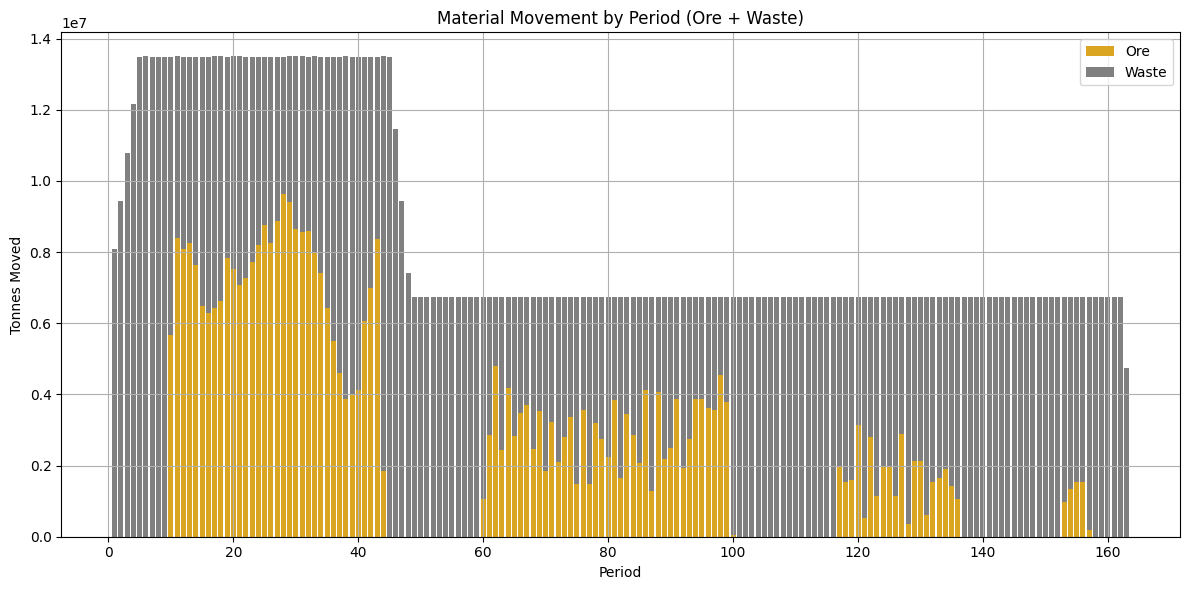

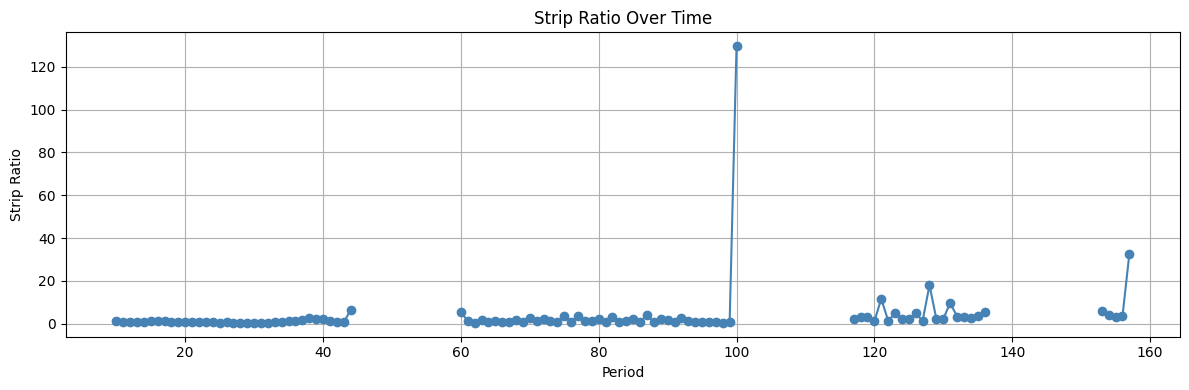

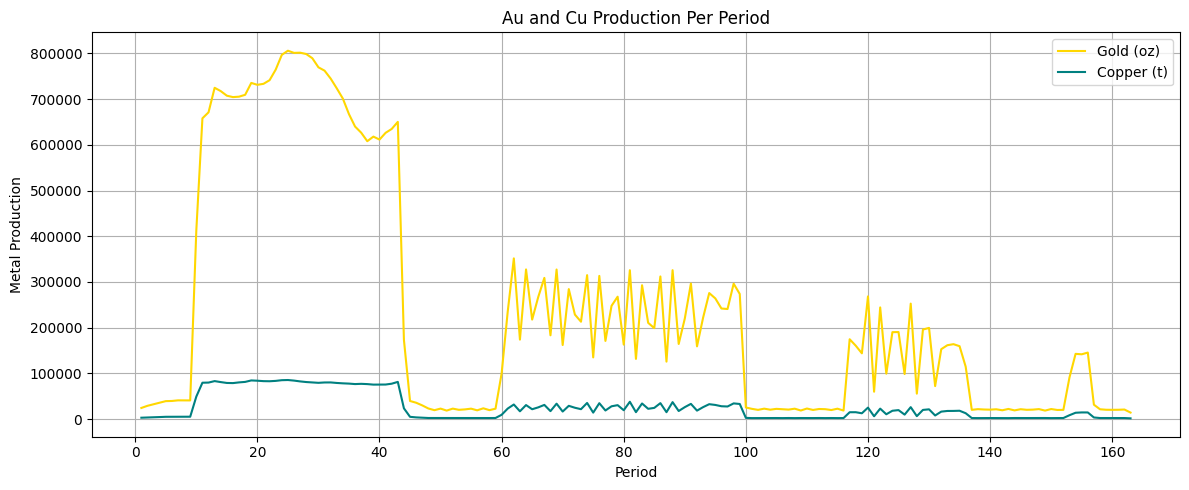

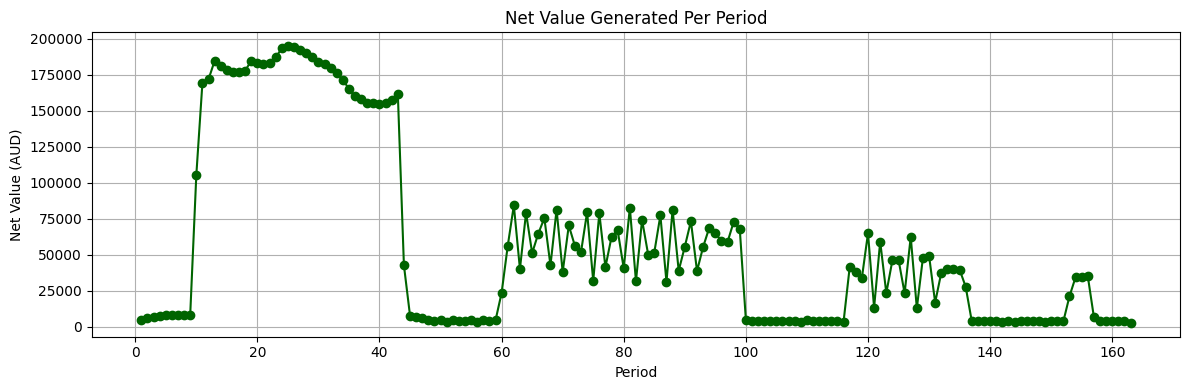

In [52]:
import matplotlib.pyplot as plt

# 📊 1. Tonnes Moved vs Period (Stacked Ore/Waste)

plt.figure(figsize=(12, 6))
plt.bar(summary["period"], summary["ore_tonnes"], label="Ore", color="goldenrod")
plt.bar(summary["period"], summary["waste_tonnes"], bottom=summary["ore_tonnes"], label="Waste", color="grey")
plt.xlabel("Period")
plt.ylabel("Tonnes Moved")
plt.title("Material Movement by Period (Ore + Waste)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧮 2. Strip Ratio Over Time
plt.figure(figsize=(12, 4))
plt.plot(summary["period"], summary["strip_ratio"], marker='o', color="steelblue")
plt.xlabel("Period")
plt.ylabel("Strip Ratio")
plt.title("Strip Ratio Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()


# 🪙 3. Au & Cu Production Per Period
plt.figure(figsize=(12, 5))
plt.plot(summary["period"], summary["Au_oz"], label="Gold (oz)", color="gold")
plt.plot(summary["period"], summary["Cu_tonnes"], label="Copper (t)", color="teal")
plt.xlabel("Period")
plt.ylabel("Metal Production")
plt.title("Au and Cu Production Per Period")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 💰 4. Net Value Per Period
plt.figure(figsize=(12, 4))
plt.plot(summary["period"], summary["net_value"], color="darkgreen", marker="o")
plt.xlabel("Period")
plt.ylabel("Net Value (AUD)")
plt.title("Net Value Generated Per Period")
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:


# --- Enhanced Gantt-style Visualisation (Global + Highlighted Period) ---

# Widgets
block_type_dropdown = widgets.Dropdown(
	options=["All", "Ore", "Waste"],
	value="All",
	description="Block Type:"
)

highlight_period_slider = widgets.IntSlider(
	value=1,
	min=1,
	max=scheduled_blocks["period"].max(),
	step=1,
	description="Highlight Period:"
)

def update_gantt_all(block_type, highlight_period):
	clear_output(wait=True)

	# Filter
	plot_df = scheduled_blocks.copy()
	if block_type != "All":
		plot_df = plot_df[plot_df["block_type"] == block_type]

	# Highlight current period
	plot_df["highlight"] = plot_df["period"] == highlight_period

	plt.figure(figsize=(14, 6))
	sns.stripplot(
		data=plot_df, x="period", y="bench",
		hue="highlight", palette={True: "red", False: "lightgrey"},
		jitter=0.3, alpha=0.6, dodge=False
	)
	plt.gca().invert_yaxis()
	plt.xlabel("Period")
	plt.ylabel("Bench (Z)")
	plt.title("Full Gantt-style Mining Sequence (All Periods) – Highlighted Period in Red")
	plt.legend(title="Highlighted")
	plt.grid(True)
	plt.tight_layout()
	plt.show()

	display(block_type_dropdown, highlight_period_slider)

widgets.interact(update_gantt_all,
				 block_type=block_type_dropdown,
				 highlight_period=highlight_period_slider)

# --- 3D Animation with Plotly ---

fig = px.scatter_3d(
	scheduled_blocks,
	x="x", y="y", z="z",
	color="period",
	animation_frame="period",
	size_max=4,
	color_continuous_scale="Viridis",
	opacity=0.5,
	title="Animated 3D Mining Schedule"
)
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.show()

### STEP x: Export to CSV

In [ ]:
scheduled_blocks.to_csv("../data/scheduled_block_model.csv", index=False)
summary.to_csv("../data/schedule_summary.csv", index=False)
print("✅ Exported pit schedule and summary to ../data/")

In [ ]:
scheduled_blocks.head()

🔢 1. Equipment Visual Overlay (Plan View)

In [ ]:
# --- Equipment Overlay on Plan View ---

def overlay_equipment(ax, positions, shape="rectangle", label="Truck", size=20):
	for (x, y) in positions:
		if shape == "rectangle":
			rect = plt.Rectangle((x - size / 2, y - size / 2), size, size,
								 linewidth=1, edgecolor="black", facecolor="grey", alpha=0.6)
			ax.add_patch(rect)
			ax.text(x, y, label, ha='center', va='center', fontsize=8, color='white')

equipment_positions = [(50, 50), (100, 100), (150, 50)]  # Example XY positions

def plot_z_slice(z_value):
	clear_output(wait=True)

	slice_df = scheduled_blocks[np.isclose(scheduled_blocks["z"], z_value)]
	if slice_df.empty:
		print(f"No data at Z={z_value}")
		display(z_dropdown)
		return

	fig, ax = plt.subplots(figsize=(10, 8))
	sns.scatterplot(
		data=slice_df,
		x="x", y="y", hue="phase",
		palette="Set1", s=80, edgecolor="black", ax=ax
	)

	overlay_equipment(ax, equipment_positions, label="Truck", size=20)

	plt.title(f"Mining Phases at Z={z_value:.1f} m")
	plt.xlabel("X (m)")
	plt.ylabel("Y (m)")
	plt.gca().set_aspect("equal")
	plt.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.grid(True)
	plt.tight_layout()
	plt.show()
	display(z_dropdown)

def on_filter_change(change):
	plot_z_slice(z_dropdown.value, list(phase_multiselect.value))

z_dropdown.observe(on_filter_change, names="value")
phase_multiselect.observe(on_filter_change, names="value")

# --- Toggle for Metric (tonnes / value / volume) ---
metric_toggle = widgets.Dropdown(
	options=["tonnes", "value_per_tonne", "volume_m3"],
	value="tonnes",
	description="Metric:"
)

# --- Initial Display ---
display(z_dropdown, phase_multiselect)
plot_z_slice(z_dropdown.value)

def get_metric_value(df, metric):
	if metric == "tonnes":
		return df["tonnes"]
	elif metric == "value_per_tonne":
		return df["value_per_tonne"] * df["tonnes"]
	elif metric == "volume_m3":
		return df["volume_m3"]

